In [1]:
import os
import re
import time
import random
from pathlib import Path


try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else []

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.filters import threshold_multiotsu
from skimage.morphology import remove_small_objects, skeletonize
from skimage.measure import label, regionprops

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 120)


CONFIG = {
    "dataset_hint": "/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset",
    "preview_max_images": 6,
    "generated_mask_dir": "/kaggle/working/generated_masks",
    "overlay_dir": "/kaggle/working/generated_overlays",
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}



def show_progress(iterable, desc=None, total=None, leave=True, unit="item"):
    """Return a tqdm progress iterator; keeps loops readable in notebook cells."""
    return tqdm(iterable, desc=desc, total=total, leave=leave, unit=unit)


In [2]:
def normalize_stem(path_or_stem):
    """Normalize a filename stem so image and mask names can be matched."""
    stem = Path(str(path_or_stem)).stem.lower()
    replacements = [
        "_mask", "-mask", " mask",
        "_masks", "-masks",
        "_gt", "-gt", "_groundtruth", "-groundtruth",
        "_label", "-label", "_labels", "-labels",
        "_seg", "-seg", "_segmentation", "-segmentation",
        "_binary", "-binary"
    ]
    for token in replacements:
        stem = stem.replace(token, "")
    stem = re.sub(r"[^a-z0-9]+", "", stem)
    return stem


def has_mask_indicator(path):
    """Return True if a path likely belongs to a mask/label/ground-truth directory or file."""
    p = Path(path)
    parts = [part.lower() for part in p.parts]
    name = p.stem.lower()

    # Added label_images_semantic for the Semantic Drone Dataset
    mask_tokens = {
        "mask",
        "masks",
        "label",
        "labels",
        "label_images_semantic",
        "gt",
        "groundtruth",
        "ground_truth",
        "annotations",
        "annotation"
    }

    if any(part in mask_tokens for part in parts):
        return True

    filename_tokens = [
        "_mask", "-mask",
        "mask_",
        "_gt", "-gt",
        "_label", "-label",
        "_seg", "-seg"
    ]

    return any(tok in name for tok in filename_tokens)


def candidate_dataset_roots():
    """Return the Semantic Drone Dataset root."""

    root = Path(CONFIG["dataset_hint"])

    if not root.exists():
        raise FileNotFoundError(
            f"Dataset not found:\n{root}"
        )

    return [root.resolve()]


def discover_files(root):
    """
    Load RGB images and semantic masks from the Semantic Drone Dataset.
    """

    root = Path(root)

    image_dir = root / "original_images"
    mask_dir = root / "label_images_semantic"

    if not image_dir.exists():
        raise FileNotFoundError(
            f"Image directory not found:\n{image_dir}"
        )

    if not mask_dir.exists():
        raise FileNotFoundError(
            f"Mask directory not found:\n{mask_dir}"
        )

    image_files = sorted(
        p for p in show_progress(
            image_dir.iterdir(),
            desc="Loading original images",
            leave=False,
            unit="image"
        )
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

    mask_files = sorted(
        p for p in show_progress(
            mask_dir.iterdir(),
            desc="Loading semantic masks",
            leave=False,
            unit="mask"
        )
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

    return image_files, mask_files


def infer_split(path):
    parts = [part.lower() for part in Path(path).parts]

    if "train" in parts or "training" in parts:
        return "train"

    if "valid" in parts or "val" in parts or "validation" in parts:
        return "valid"

    if "test" in parts or "testing" in parts:
        return "test"

    # Semantic Drone Dataset has no train/valid/test folders
    return "all"


def pair_images_and_masks(image_files, mask_files):
    """Match images with masks using normalized stems rather than folder-specific assumptions."""
    mask_lookup = {}

    # Build a lookup table from several normalized mask-name variants.
    for m in show_progress(
        mask_files,
        desc="Indexing masks",
        leave=False,
        unit="mask"
    ):
        keys = {
            normalize_stem(m.stem),
            re.sub(r"[^a-z0-9]+", "", m.stem.lower())
        }

        for key in keys:
            if key and key not in mask_lookup:
                mask_lookup[key] = m

    rows = []

    for img in show_progress(
        image_files,
        desc="Pairing images with masks",
        leave=False,
        unit="image"
    ):
        key = normalize_stem(img.stem)
        mask = mask_lookup.get(key)

        rows.append({
            "split": infer_split(img),
            "image_path": str(img),
            "mask_path": str(mask) if mask is not None else None,
            "image_name": img.name,
            "pair_key": key,
        })

    return pd.DataFrame(rows)


# ---------------------------------------------------------------------
# Main execution
# ---------------------------------------------------------------------

roots = candidate_dataset_roots()

print("Candidate roots checked:")

for r in roots[:12]:
    print("  ", r)

best_root = None
best_df = pd.DataFrame()
best_counts = (0, 0, 0)

for root in roots:

    image_files, mask_files = discover_files(root)

    if len(image_files) == 0:
        continue

    df_try = pair_images_and_masks(image_files, mask_files)

    paired_count = df_try["mask_path"].notna().sum()

    score = (
        paired_count,
        len(image_files),
        len(mask_files)
    )

    if score > best_counts:
        best_counts = score
        best_root = root
        best_df = df_try.copy()

if best_root is None or len(best_df) == 0:
    raise FileNotFoundError(
        "No image files were found. Add the Semantic Drone Dataset to the notebook, then rerun this cell."
    )

DATASET_ROOT = Path(best_root)

df_pairs = (
    best_df
    .sort_values(["split", "image_name"])
    .reset_index(drop=True)
)

print(f"\nSelected dataset root: {DATASET_ROOT}")
print(f"Discovered images: {len(df_pairs)}")
print(f"Paired masks: {df_pairs['mask_path'].notna().sum()}")
print(f"Unpaired images: {df_pairs['mask_path'].isna().sum()}")

display(df_pairs.head(10))


display(
    df_pairs.groupby("split").agg(
        images=("image_path", "count"),
        masks=("mask_path", lambda s: s.notna().sum())
    )
)

Candidate roots checked:
   /kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset


Loading original images: 0image [00:00, ?image/s]

Loading semantic masks: 0mask [00:00, ?mask/s]

Indexing masks:   0%|          | 0/400 [00:00<?, ?mask/s]

Pairing images with masks:   0%|          | 0/400 [00:00<?, ?image/s]


Selected dataset root: /kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset
Discovered images: 400
Paired masks: 400
Unpaired images: 0


,split,image_path,mask_path,image_name,pair_key
0,all,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/000.jpg,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/label_images_semantic/000.png,000.jpg,000
1,all,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/001.jpg,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/label_images_semantic/001.png,001.jpg,001
2,all,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/002.jpg,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/label_images_semantic/002.png,002.jpg,002
3,all,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/003.jpg,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/label_images_semantic/003.png,003.jpg,003
4,all,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/004.jpg,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/label_images_semantic/004.png,004.jpg,004
5,all,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/005.jpg,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/label_images_semantic/005.png,005.jpg,005
6,all,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/006.jpg,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/label_images_semantic/006.png,006.jpg,006
7,all,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/008.jpg,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/label_images_semantic/008.png,008.jpg,008
8,all,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/011.jpg,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/label_images_semantic/011.png,011.jpg,011
9,all,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/013.jpg,/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/label_images_semantic/013.png,013.jpg,013


,images,masks
split,,
all,400,400


In [3]:
from sklearn.model_selection import train_test_split

# ==========================================================
# Task B - Leakage-Safe Dataset Split
# ==========================================================

# First split:
# 70% Training
# 30% Temporary (Validation + Test)

train_df, temp_df = train_test_split(
    df_pairs,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

# Second split:
# Divide the remaining 30%
# into Validation (15%)
# and Test (15%)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

# Reset dataframe indices

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [4]:
# ==========================================================
# Training Configuration
# ==========================================================

CONFIG = {

    # Model
    "model": "DeepLabV3-ResNet50",
    "backbone": "ResNet50",
    "pretrained": True,

    # Dataset
    "num_classes": 24,
    "image_size": 512,

    # Training
    "batch_size": 8,
    "epochs": 50,

    # Optimizer
    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,

    # Scheduler
    "scheduler": "ReduceLROnPlateau",

    # Loss
    "loss_function": "CrossEntropyLoss",

    # DataLoader
    "num_workers": 4,
    "pin_memory": True
}

CONFIG

{'model': 'DeepLabV3-ResNet50',
 'backbone': 'ResNet50',
 'pretrained': True,
 'num_classes': 24,
 'image_size': 512,
 'batch_size': 8,
 'epochs': 50,
 'optimizer': 'AdamW',
 'learning_rate': 0.0001,
 'weight_decay': 0.0001,
 'scheduler': 'ReduceLROnPlateau',
 'loss_function': 'CrossEntropyLoss',
 'num_workers': 4,
 'pin_memory': True}

In [5]:
# # ==========================================================
# # Import Albumentations
# # ==========================================================

# import albumentations as A

# # ==========================================================
# # Task C - Data Augmentation Pipeline
# # ==========================================================

# train_transform = A.Compose([

#     # Randomly flip the image horizontally
#     A.HorizontalFlip(
#         p=0.5
#     ),

#     # Randomly rotate the image within ±15 degrees
#     A.Rotate(
#         limit=15,
#         border_mode=cv2.BORDER_CONSTANT,
#         p=0.5
#     ),

#     # Randomly change image brightness and contrast
#     A.RandomBrightnessContrast(
#         brightness_limit=0.2,
#         contrast_limit=0.2,
#         p=0.3
#     ),

#     # Randomly apply Gaussian blur
#     A.GaussianBlur(
#         blur_limit=(3, 5),
#         p=0.2
#     )

# ])

# print("Training augmentation pipeline created successfully.")

In [6]:
# ==========================================================
# DeepLabV3 Notebook
# Setup & Imports
# ==========================================================

import os
import time
import json
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights
)

from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [7]:
# ==========================================================
# Load Dataset Split
# ==========================================================

import pandas as pd

SPLIT_DIR = "/kaggle/input/datasets/mashrur135/my-splits"

train_df = pd.read_csv(f"{SPLIT_DIR}/train_split.csv")
valid_df = pd.read_csv(f"{SPLIT_DIR}/valid_split.csv")
test_df  = pd.read_csv(f"{SPLIT_DIR}/test_split.csv")

print("Train :", len(train_df))
print("Valid :", len(valid_df))
print("Test  :", len(test_df))

Train : 280
Valid : 60
Test  : 60


In [8]:
class SegmentationDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]


        image = cv2.imread(
            row["image_path"]
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )


        mask = cv2.imread(
            row["mask_path"],
            cv2.IMREAD_GRAYSCALE
        )


        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]


        return image, mask.long()

In [9]:
# ==========================================================
# Albumentations Transforms
# ==========================================================

train_transform = A.Compose([

    A.Resize(512, 512),

    A.HorizontalFlip(p=0.5),

    A.Rotate(
        limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),

    A.GaussianBlur(
        blur_limit=(3,5),
        p=0.2
    ),

    A.Normalize(),

    ToTensorV2()

])

valid_transform = A.Compose([

    A.Resize(512,512),

    A.Normalize(),

    ToTensorV2()

])

test_transform = valid_transform

In [10]:
# ==========================================================
# Create Dataset Objects
# ==========================================================

train_dataset = SegmentationDataset(
    train_df,
    transform=train_transform
)

valid_dataset = SegmentationDataset(
    valid_df,
    transform=valid_transform
)

test_dataset = SegmentationDataset(
    test_df,
    transform=test_transform
)

In [11]:
# ==========================================================
# DataLoaders
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 35
Validation batches: 8
Test batches: 8


In [12]:
# ==========================================================
# DeepLabV3 Model
# ==========================================================

NUM_CLASSES = 24

weights = DeepLabV3_ResNet50_Weights.DEFAULT

model = deeplabv3_resnet50(
    weights=weights
)

# Replace the classifier for our dataset
model.classifier[4] = nn.Conv2d(
    in_channels=256,
    out_channels=NUM_CLASSES,
    kernel_size=1
)

model = model.to(DEVICE)

print(model)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 184MB/s]


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [13]:
# # ==========================================================
# # Training Configuration
# # ==========================================================

# CONFIG = {

#     # Model
#     "model": "DeepLabV3-ResNet50",
#     "backbone": "ResNet50",
#     "pretrained": True,

#     # Dataset
#     "num_classes": NUM_CLASSES,
#     "image_size": 512,

#     # Training
#     "batch_size": 8,
#     "epochs": 50,

#     # Optimizer
#     "optimizer": "AdamW",
#     "learning_rate": 1e-4,
#     "weight_decay": 1e-4,

#     # Scheduler
#     "scheduler": "ReduceLROnPlateau",

#     # Loss
#     "loss_function": "CrossEntropyLoss",

#     # DataLoader
#     "num_workers": 4,
#     "pin_memory": True
# }

# CONFIG

In [14]:
# ==========================================================
# Loss Function, Optimizer & Scheduler
# ==========================================================

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"]
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",          # maximize validation mIoU
    factor=0.5,          # reduce LR by half
    patience=3,          # wait 3 epochs before reducing LR
)

print("Loss Function :", CONFIG["loss_function"])
print("Optimizer     :", CONFIG["optimizer"])
print("Scheduler     :", CONFIG["scheduler"])

Loss Function : CrossEntropyLoss
Optimizer     : AdamW
Scheduler     : ReduceLROnPlateau


In [15]:
# ==========================================================
# Metric Function - Mean IoU
# ==========================================================

def compute_iou(pred, target, num_classes):
    """
    Compute mean IoU and per-class IoU
    for multi-class semantic segmentation.
    """

    ious = []

    pred = pred.view(-1)
    target = target.view(-1)

    for cls in range(num_classes):

        pred_class = pred == cls
        target_class = target == cls

        intersection = (
            pred_class & target_class
        ).sum().item()

        union = (
            pred_class | target_class
        ).sum().item()


        if union == 0:
            ious.append(float("nan"))

        else:
            ious.append(
                intersection / union
            )


    mean_iou = np.nanmean(ious)

    return mean_iou, ious


print("IoU metric function ready")

IoU metric function ready


In [16]:
# ==========================================================
# Training Loop - DeepLabV3
# ==========================================================

best_miou = 0.0

train_losses = []
valid_losses = []
valid_mious = []

start_time = time.time()


for epoch in range(CONFIG["epochs"]):

    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")

    # ======================================================
    # Training
    # ======================================================

    model.train()

    train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc="Training"
    )

    for images, masks in train_bar:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE).long()


        optimizer.zero_grad()


        # DeepLabV3 returns dictionary
        outputs = model(images)["out"]


        loss = criterion(
            outputs,
            masks
        )


        loss.backward()

        optimizer.step()


        train_loss += loss.item()


        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    avg_train_loss = train_loss / len(train_loader)

    train_losses.append(avg_train_loss)



    # ======================================================
    # Validation
    # ======================================================

    model.eval()

    valid_loss = 0.0
    valid_iou = []


    with torch.no_grad():

        valid_bar = tqdm(
            valid_loader,
            desc="Validation"
        )


        for images, masks in valid_bar:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE).long()


            outputs = model(images)["out"]


            loss = criterion(
                outputs,
                masks
            )

            valid_loss += loss.item()


            # Convert prediction:
            # [B,24,H,W] -> [B,H,W]

            predictions = torch.argmax(
                outputs,
                dim=1
            )


            miou, _ = compute_iou(
                predictions.cpu(),
                masks.cpu(),
                CONFIG["num_classes"]
            )


            valid_iou.append(miou)



    avg_valid_loss = valid_loss / len(valid_loader)

    avg_valid_miou = np.nanmean(valid_iou)


    valid_losses.append(avg_valid_loss)

    valid_mious.append(avg_valid_miou)



    # Scheduler update
    scheduler.step(avg_valid_miou)



    # ======================================================
    # Save Best Model
    # ======================================================

    if avg_valid_miou > best_miou:

        best_miou = avg_valid_miou

        torch.save(
            model.state_dict(),
            "best_deeplabv3.pth"
        )

        print("Best model saved!")


    print(
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Valid Loss: {avg_valid_loss:.4f} | "
        f"Valid mIoU: {avg_valid_miou:.4f}"
    )



training_time = time.time() - start_time


print("\nTraining Complete")
print(
    f"Total Training Time: {training_time/60:.2f} minutes"
)

print(
    f"Best Validation mIoU: {best_miou:.4f}"
)


Epoch 1/50


Training:   0%|          | 0/35 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Best model saved!
Train Loss: 2.5064 | Valid Loss: 1.7339 | Valid mIoU: 0.1314

Epoch 2/50


Training:   0%|          | 0/35 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 0.1711 | Valid Loss: 0.3616 | Valid mIoU: 0.5387

Epoch 50/50


Training:   0%|          | 0/35 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 0.1704 | Valid Loss: 0.3641 | Valid mIoU: 0.5397

Training Complete
Total Training Time: 133.73 minutes
Best Validation mIoU: 0.5416


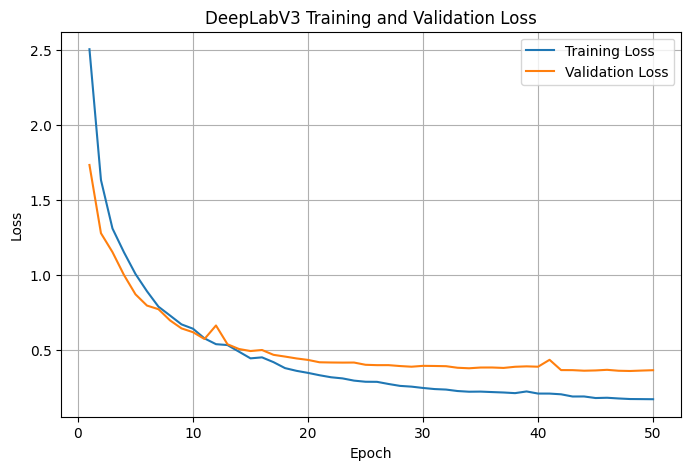

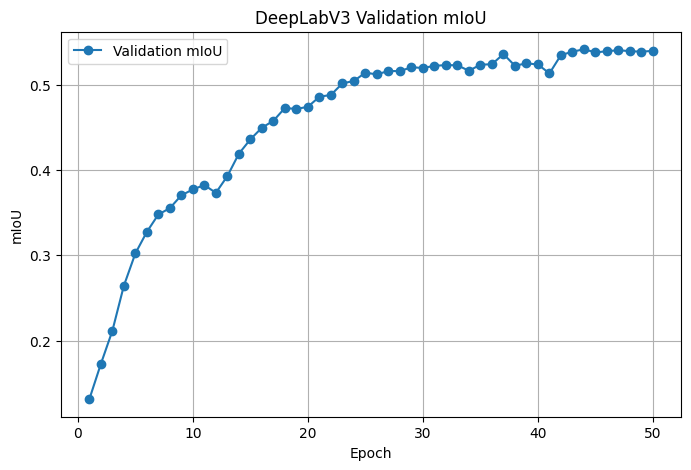

In [17]:
# ==========================================================
# Training Curves
# ==========================================================

epochs = range(1, len(train_losses) + 1)


# -----------------------------
# Loss Curve
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    valid_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DeepLabV3 Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()



# -----------------------------
# Validation mIoU Curve
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    valid_mious,
    marker="o",
    label="Validation mIoU"
)

plt.xlabel("Epoch")
plt.ylabel("mIoU")

plt.title("DeepLabV3 Validation mIoU")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
# ==========================================================
# Load Best Model for Test Evaluation
# ==========================================================

# Create a fresh model
model.load_state_dict(
    torch.load(
        "best_deeplabv3.pth",
        map_location=DEVICE
    )
)

model.to(DEVICE)

# Evaluation mode
model.eval()

print("Best DeepLabV3 model loaded successfully.")

Best DeepLabV3 model loaded successfully.


In [19]:
# ==========================================================
# Test Prediction
# ==========================================================

all_preds = []
all_masks = []

model.eval()


with torch.no_grad():

    for images, masks in tqdm(
        test_loader,
        desc="Testing"
    ):

        images = images.to(DEVICE)

        masks = masks.to(DEVICE).long()


        # Forward pass
        outputs = model(images)["out"]


        # Choose class with highest probability
        preds = torch.argmax(
            outputs,
            dim=1
        )


        # Store results
        all_preds.append(
            preds.cpu()
        )

        all_masks.append(
            masks.cpu()
        )



# Combine all batches

all_preds = torch.cat(
    all_preds,
    dim=0
)

all_masks = torch.cat(
    all_masks,
    dim=0
)


print("Prediction shape:", all_preds.shape)
print("Mask shape:", all_masks.shape)

Testing:   0%|          | 0/8 [00:00<?, ?it/s]

Prediction shape: torch.Size([60, 512, 512])
Mask shape: torch.Size([60, 512, 512])


In [20]:
 # ==========================================================
# Evaluation Metric Functions
# ==========================================================

import numpy as np
import torch


# ----------------------------------------------------------
# Pixel Accuracy
# ----------------------------------------------------------

def pixel_accuracy(preds, masks):

    correct = (preds == masks).sum().item()
    total = masks.numel()

    return correct / total



# ----------------------------------------------------------
# Mean Pixel Accuracy
# ----------------------------------------------------------

def mean_pixel_accuracy(preds, masks, num_classes):

    class_acc = []

    for cls in range(num_classes):

        gt = (masks == cls)

        total = gt.sum().item()

        if total == 0:
            continue

        correct = ((preds == cls) & gt).sum().item()

        class_acc.append(correct / total)

    return np.mean(class_acc)



# ----------------------------------------------------------
# Dice Score
# ----------------------------------------------------------

def dice_score(preds, masks, num_classes):

    dice_scores = []

    for cls in range(num_classes):

        pred = (preds == cls)
        gt = (masks == cls)

        intersection = (pred & gt).sum().item()

        denominator = (
            pred.sum().item()
            +
            gt.sum().item()
        )

        if denominator == 0:
            continue

        dice = (
            2 * intersection
        ) / denominator

        dice_scores.append(dice)

    return np.mean(dice_scores)



# ----------------------------------------------------------
# Per-Class IoU
# ----------------------------------------------------------

def per_class_iou(preds, masks, num_classes):

    ious = []

    for cls in range(num_classes):

        pred = (preds == cls)
        gt = (masks == cls)

        intersection = (
            pred & gt
        ).sum().item()

        union = (
            pred | gt
        ).sum().item()


        if union == 0:
            ious.append(np.nan)

        else:
            ious.append(
                intersection / union
            )

    return ious



# ----------------------------------------------------------
# Mean IoU
# ----------------------------------------------------------

def mean_iou(preds, masks, num_classes):

    ious = per_class_iou(
        preds,
        masks,
        num_classes
    )

    return np.nanmean(ious)



print("Evaluation metric functions loaded.")

Evaluation metric functions loaded.


In [21]:
# ==========================================================
# Task F - Quantitative Evaluation
# ==========================================================

# Mean IoU
miou = mean_iou(
    all_preds,
    all_masks,
    NUM_CLASSES
)


# Per-class IoU
class_ious = per_class_iou(
    all_preds,
    all_masks,
    NUM_CLASSES
)


# Pixel Accuracy
pixel_acc = pixel_accuracy(
    all_preds,
    all_masks
)


# Mean Pixel Accuracy
mean_pixel_acc = mean_pixel_accuracy(
    all_preds,
    all_masks,
    NUM_CLASSES
)


# Dice coefficient
dice = dice_score(
    all_preds,
    all_masks,
    NUM_CLASSES
)


print("="*50)
print("DeepLabV3 Test Results")
print("="*50)

print(f"Mean IoU              : {miou:.4f}")
print(f"Pixel Accuracy        : {pixel_acc:.4f}")
print(f"Mean Pixel Accuracy   : {mean_pixel_acc:.4f}")
print(f"Dice Coefficient      : {dice:.4f}")

DeepLabV3 Test Results
Mean IoU              : 0.5810
Pixel Accuracy        : 0.9022
Mean Pixel Accuracy   : 0.6673
Dice Coefficient      : 0.6729


In [22]:
# ==========================================================
# Per-Class IoU Results
# ==========================================================

class_names = [
    "unlabeled",
    "paved-area",
    "dirt",
    "grass",
    "gravel",
    "water",
    "rocks",
    "pool",
    "vegetation",
    "roof",
    "wall",
    "window",
    "door",
    "fence",
    "fence-pole",
    "person",
    "dog",
    "car",
    "bicycle",
    "tree",
    "bald-tree",
    "ar-marker",
    "obstacle",
    "conflicting"
]


iou_df = pd.DataFrame({
    "Class": class_names,
    "IoU": class_ious
})


display(iou_df)

,Class,IoU
0,unlabeled,0.003516
1,paved-area,0.919093
2,dirt,0.500420
3,grass,0.935336
4,gravel,0.757385
5,water,0.875991
6,rocks,0.483768
7,pool,0.918132
8,vegetation,0.629121
9,roof,0.836221


In [23]:
# ==========================================================
# Pixel-level Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


# Flatten predictions and masks

y_true = all_masks.numpy().flatten()
y_pred = all_preds.numpy().flatten()


# Create confusion matrix

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)


print("Confusion Matrix Shape:", cm.shape)

Confusion Matrix Shape: (24, 24)


In [24]:
# # ==========================================================
# # Confusion Matrix with Values
# # ==========================================================

# plt.figure(figsize=(14,12))

# plt.imshow(cm)

# plt.title("DeepLabV3 Pixel-level Confusion Matrix")

# plt.xlabel("Predicted Class")
# plt.ylabel("Ground Truth Class")

# plt.colorbar()


# # Add numbers inside cells
# for i in range(NUM_CLASSES):
#     for j in range(NUM_CLASSES):
#         plt.text(
#             j,
#             i,
#             cm[i, j],
#             ha="center",
#             va="center",
#             fontsize=6
#         )


# plt.show()

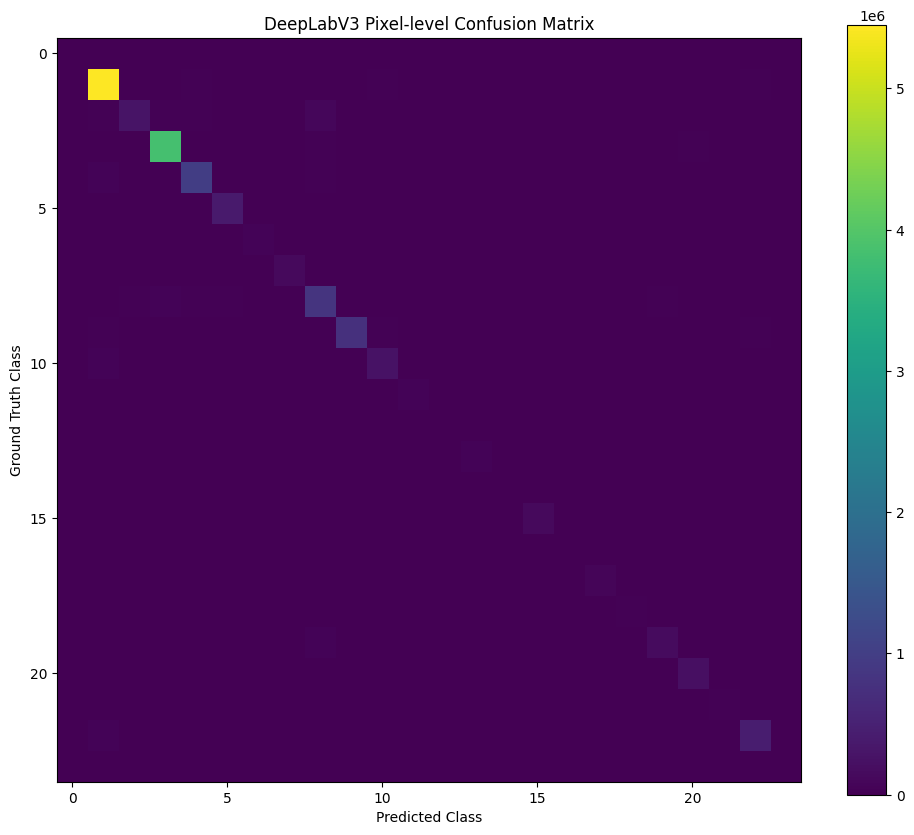

In [25]:
# ==========================================================
# Plot Confusion Matrix
# ==========================================================

plt.figure(figsize=(12,10))

plt.imshow(cm)

plt.title("DeepLabV3 Pixel-level Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Ground Truth Class")

plt.colorbar()

plt.show()

In [26]:
# # Normalize confusion matrix by ground truth class

# cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# plt.figure(figsize=(12,10))

# plt.imshow(cm_normalized)

# plt.title("Normalized Confusion Matrix")

# plt.xlabel("Predicted Class")
# plt.ylabel("Ground Truth Class")

# plt.colorbar()

# plt.show()

In [27]:
# ==========================================================
# Task G - Per Image IoU
# ==========================================================

def per_image_iou(pred, mask, num_classes):

    ious = []

    for cls in range(num_classes):

        pred_cls = (pred == cls)
        mask_cls = (mask == cls)

        intersection = (pred_cls & mask_cls).sum()

        union = (pred_cls | mask_cls).sum()

        if union == 0:
            continue

        ious.append(
            intersection / union
        )

    return np.mean(ious)



image_ious = []

for i in range(len(all_preds)):

    score = per_image_iou(
        all_preds[i],
        all_masks[i],
        NUM_CLASSES
    )

    image_ious.append(score)


image_ious = np.array(image_ious)


print("Number of test images:", len(image_ious))
print("Worst IoU:", image_ious.min())

Number of test images: 60
Worst IoU: 0.20456286


In [28]:
# ==========================================================
# Task G - Find Worst Test Images
# ==========================================================

def calculate_single_image_iou(pred, mask, num_classes):

    ious = []

    for cls in range(num_classes):

        pred_cls = (pred == cls)
        mask_cls = (mask == cls)

        intersection = (pred_cls & mask_cls).sum().item()
        union = (pred_cls | mask_cls).sum().item()

        if union == 0:
            continue

        ious.append(intersection / union)

    return np.mean(ious)



# Calculate IoU for every test image

image_iou_scores = []

for i in range(len(all_preds)):

    score = calculate_single_image_iou(
        all_preds[i],
        all_masks[i],
        NUM_CLASSES
    )

    image_iou_scores.append(score)



image_iou_scores = np.array(image_iou_scores)



# Get worst 5 images

worst_indices = np.argsort(image_iou_scores)[:5]


print("Worst image indices:")
print(worst_indices)

print("\nIoU scores:")
for idx in worst_indices:
    print(
        f"Image {idx}: IoU = {image_iou_scores[idx]:.4f}"
    )

Worst image indices:
[26 53 18 19 34]

IoU scores:
Image 26: IoU = 0.2046
Image 53: IoU = 0.2623
Image 18: IoU = 0.2721
Image 19: IoU = 0.2725
Image 34: IoU = 0.2733


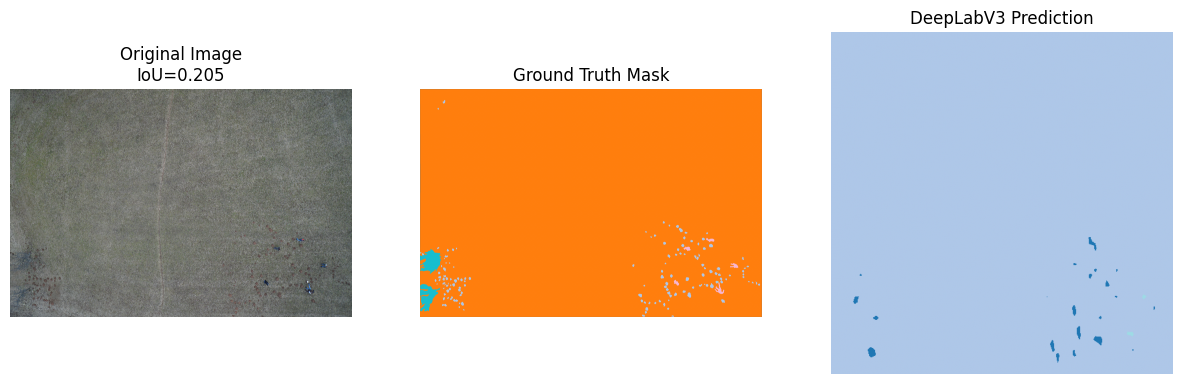

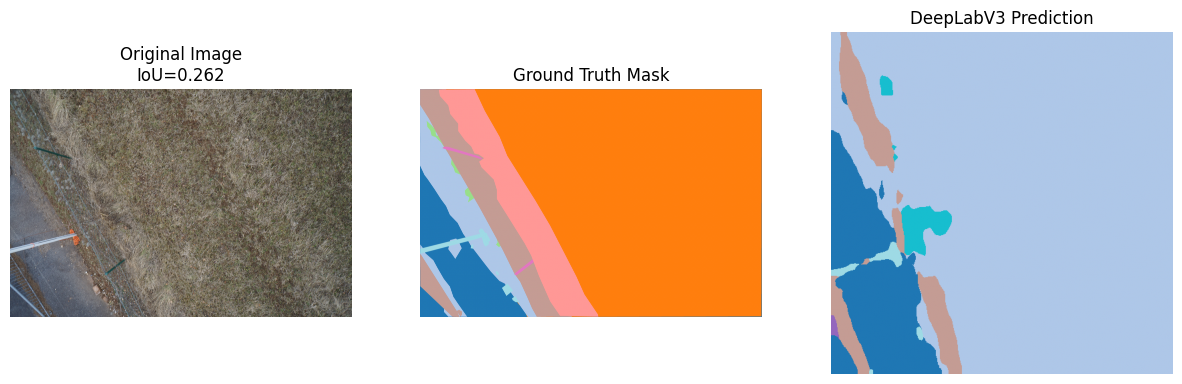

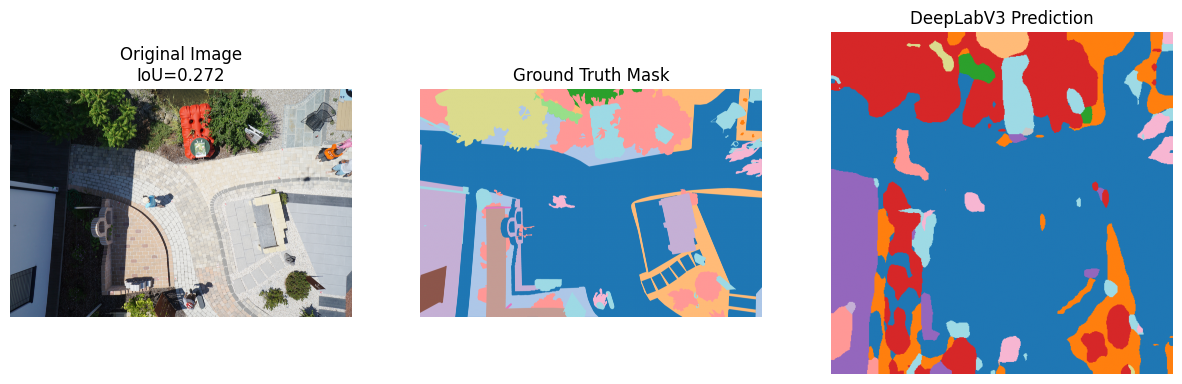

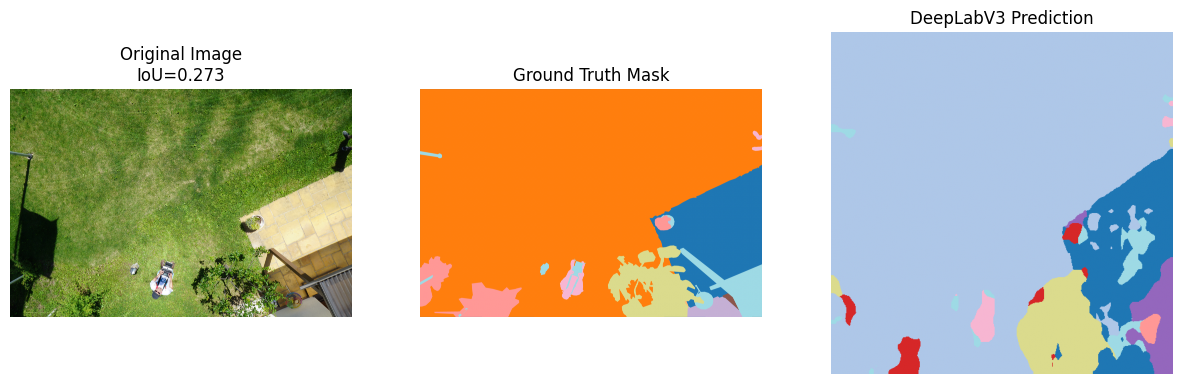

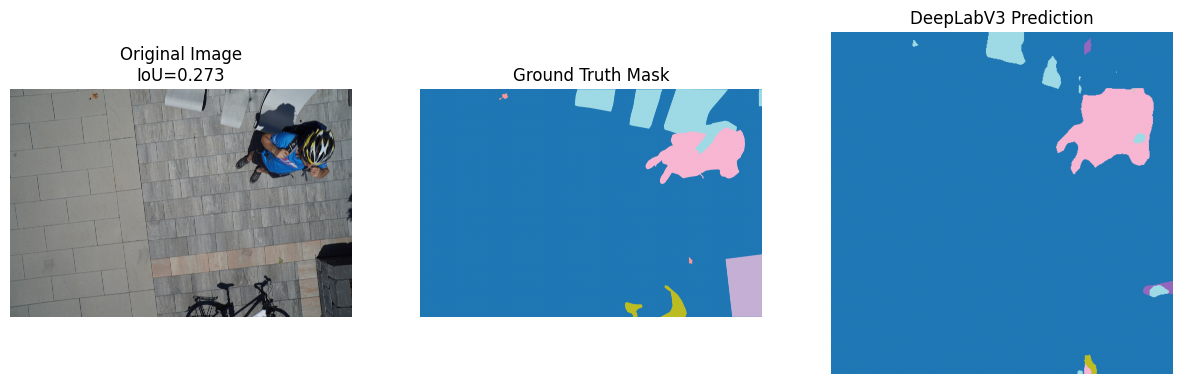

In [29]:
# ==========================================================
# Task G - Worst Image Visualization
# ==========================================================

import matplotlib.pyplot as plt
import cv2
import numpy as np


def show_error_images(indices):

    for idx in indices:

        # Get paths from test dataframe
        img_path = test_df.iloc[idx]["image_path"]
        mask_path = test_df.iloc[idx]["mask_path"]

        # Load original image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # Ground truth
        gt_mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Prediction
        pred_mask = all_preds[idx].numpy()


        plt.figure(figsize=(15,5))


        # Original image
        plt.subplot(1,3,1)
        plt.imshow(image)
        plt.title(
            f"Original Image\nIoU={image_ious[idx]:.3f}"
        )
        plt.axis("off")


        # Ground truth
        plt.subplot(1,3,2)
        plt.imshow(gt_mask, cmap="tab20")
        plt.title("Ground Truth Mask")
        plt.axis("off")


        # Prediction
        plt.subplot(1,3,3)
        plt.imshow(pred_mask, cmap="tab20")
        plt.title("DeepLabV3 Prediction")
        plt.axis("off")


        plt.show()



show_error_images(worst_indices)

In [30]:
# ==========================================================
# Task G - Find Most Confused Class Pairs
# ==========================================================

# Copy confusion matrix
cm_copy = cm.copy()

# Remove diagonal (correct predictions)
np.fill_diagonal(cm_copy, 0)


# Find largest confusion values
confusion_pairs = []

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):

        if cm_copy[i, j] > 0:
            confusion_pairs.append(
                (
                    cm_copy[i, j],
                    i,
                    j
                )
            )


# Sort highest confusion first
confusion_pairs = sorted(
    confusion_pairs,
    reverse=True
)


# Show top 10 confused pairs

for count, gt, pred in confusion_pairs[:10]:

    print(
        f"GT: {class_names[gt]} "
        f"--> Predicted: {class_names[pred]} "
        f"| Pixels: {count}"
    )

GT: dirt --> Predicted: vegetation | Pixels: 87772
GT: obstacle --> Predicted: paved-area | Pixels: 62143
GT: vegetation --> Predicted: grass | Pixels: 61361
GT: wall --> Predicted: paved-area | Pixels: 55969
GT: tree --> Predicted: vegetation | Pixels: 51776
GT: gravel --> Predicted: paved-area | Pixels: 43875
GT: gravel --> Predicted: vegetation | Pixels: 40837
GT: paved-area --> Predicted: gravel | Pixels: 40490
GT: roof --> Predicted: paved-area | Pixels: 38842
GT: vegetation --> Predicted: dirt | Pixels: 36303
